# Feature Scaling Technique
Standardization

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [9]:
dataset  = sns.load_dataset("titanic")
dataset.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
dataset.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
dataset["age"] = dataset["age"].fillna(dataset["age"].mean())
dataset["age"].isnull().sum()

np.int64(0)

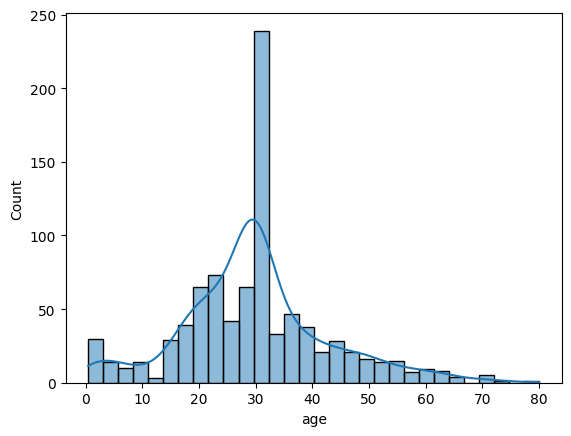

In [13]:
sns.histplot(dataset["age"],kde= True)
plt.show()

In [14]:
dataset.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
ss = StandardScaler()
ss.fit(dataset[["age"]])


StandardScaler()

In [17]:
dataset["age ss"] = pd.DataFrame(ss.transform(dataset[["age"]]),columns=["x"])

In [18]:
dataset.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age ss
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,-0.592481
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0.638789
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,-0.284663
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0.407926
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0.407926


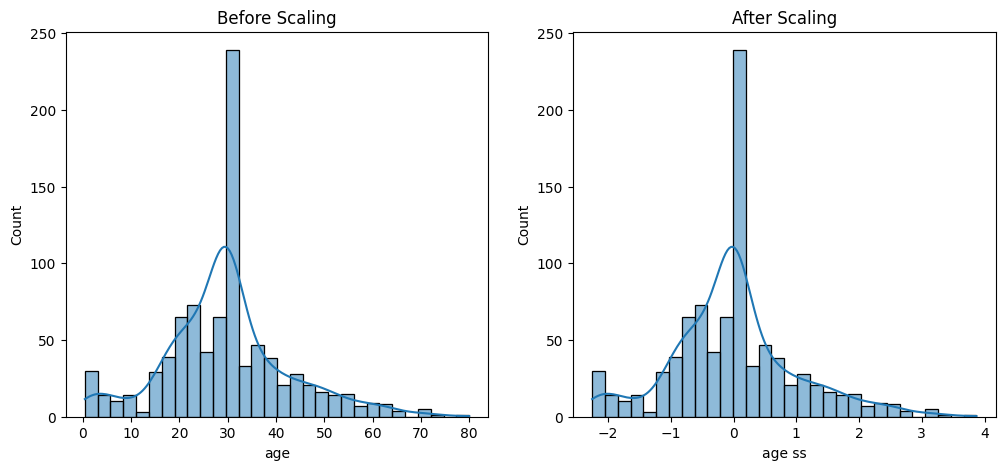

In [25]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Before Scaling")
sns.histplot(dataset["age"],kde=True)

plt.subplot(1,2,2)
plt.title("After Scaling")
sns.histplot(dataset["age ss"],kde= True)

plt.show()

In [23]:
print(dataset["age"].mean())
print(dataset["age ss"].mean())

29.69911764705882
2.2329064647904385e-16


In [24]:
print(dataset["age"].std())
print(dataset["age ss"].std())

13.002015226002884
1.0005616400330466
